# MAP challenge

In [1]:
# conda activate MAP2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import rampwf
import neurokit2 as nk

import problem

pd.set_option("display.max_columns", None)
print("sklearn", sklearn.__version__, ", need >= 1.6.0")
print("ramp", rampwf.__version__, ", need >= 0.7.0")

sklearn 1.6.0 , need >= 1.6.0
ramp 0.7.0 , need >= 0.7.0


## 1. Data Loading

In [2]:
X_df, y = problem.get_train_data()
X_df

,n_seg,subject,age,gender,domain,height,weight,bmi,id,ecg,ppg,chunk
0,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.3688673837817671, 0.3620627421921535, 0.365...","[0.40960445864963035, 0.36931866813001185, 0.3...",NaN
1,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.25735809742643956, 0.23910011930527947, 0.2...","[0.36706728559046503, 0.4034043141571599, 0.35...",NaN
2,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.13428866369506492, 0.14334834365416743, 0.1...","[0.7494333513716098, 0.8147798178151058, 0.799...",NaN
3,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.17744878960204316, 0.18312116528072353, 0.2...","[0.2668839934294831, 0.26939094339014175, 0.25...",NaN
4,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.6703874816047055, 0.5075806829705767, 0.444...","[0.27162392568169147, 0.2647447495713346, 0.24...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
300745,3590,p099038,74.0,M,m,NaN,NaN,NaN,10.0,"[0.7044025157232704, 0.27358490566037735, 0.12...","[0.23573639982308714, 0.2038920831490491, 0.17...",val
300746,3590,p099038,74.0,M,m,NaN,NaN,NaN,10.0,"[0.08440748440748441, 0.08773388773388774, 0.0...","[0.2519491177677472, 0.24743537135822732, 0.25...",val
300747,3590,p099038,74.0,M,m,NaN,NaN,NaN,10.0,"[0.10831353919239906, 0.11211401425178148, 0.1...","[0.1249399327246516, 0.11965401249399327, 0.11...",val
300748,3590,p099038,74.0,M,m,NaN,NaN,NaN,10.0,"[0.06199460916442048, 0.0840071877807727, 0.10...","[0.8313827481577808, 0.8378846987429563, 0.838...",val


## 2. ECG feature extraction

In [3]:
# Random generator
rng = np.random.default_rng(seed=1)
NB_TRAIN_SAMPLES = X_df.shape[0]
SAMPLING_RATE = (
    len(X_df["ecg"].iloc[NB_TRAIN_SAMPLES - 1]) // 10
)  # nb of data points per second
print(SAMPLING_RATE)
plt.rcParams["figure.figsize"] = [20, 5]

125


Signal#142311


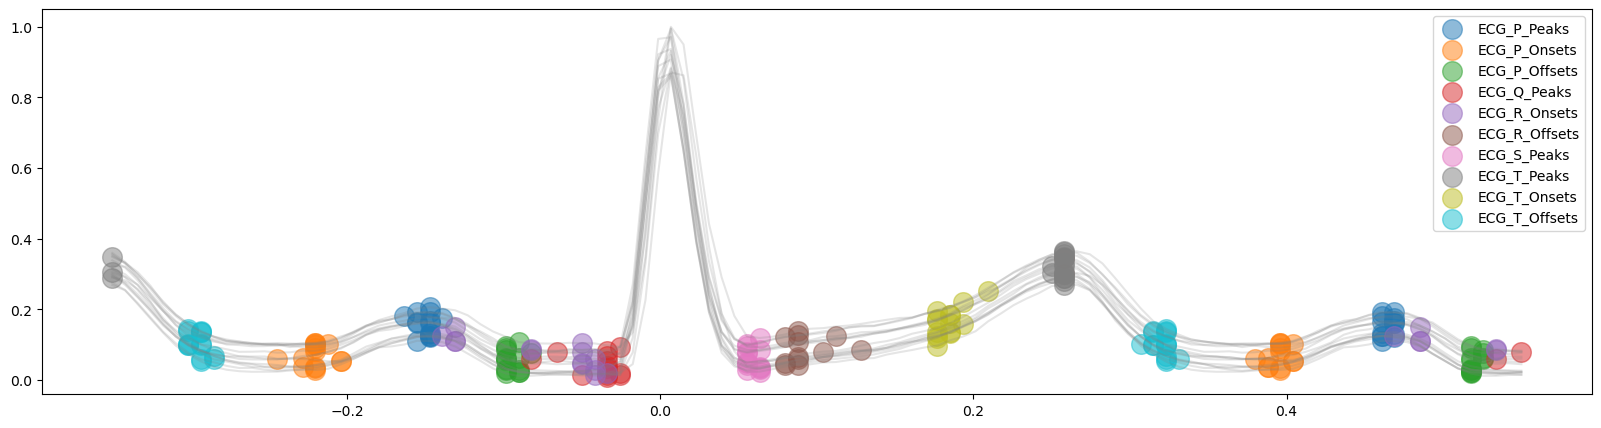

In [4]:
rand_idx = rng.choice(NB_TRAIN_SAMPLES)
ecg_signal = X_df["ecg"].iloc[rand_idx]
print(f"Signal#{rand_idx}")
signal, waves_peak = nk.ecg_delineate(
    ecg_signal, sampling_rate=SAMPLING_RATE, show=True, show_type="all"
)

In [5]:
waves_peak.keys()

dict_keys(['ECG_P_Peaks', 'ECG_P_Onsets', 'ECG_P_Offsets', 'ECG_Q_Peaks', 'ECG_R_Onsets', 'ECG_R_Offsets', 'ECG_S_Peaks', 'ECG_T_Peaks', 'ECG_T_Onsets', 'ECG_T_Offsets'])

In [6]:
ECG_DELTAS = {  # name : [end, start]
    "PR": ["ECG_R_Offsets", "ECG_P_Onsets"],
    "QS": ["ECG_S_Peaks", "ECG_Q_Peaks"],
    "RT": ["ECG_T_Offsets", "ECG_R_Onsets"],
    "TP": ["ECG_P_Offsets", "ECG_T_Onsets"],
    "PP": ["ECG_P_Peaks", "ECG_P_Onsets"],
    "TT": ["ECG_T_Peaks", "ECG_T_Onsets"],
}


def get_waves_len(waves_peak) -> dict[str : np.float64]:
    """Return the Duration of events in ECG with mean and std.
    - P, R, T waves.
    - P-R, R-T, T-P, Q-S deltas
    - heart rate"""
    val_dict = {}
    # Phase duration
    for wave_n in ["P", "R", "T"]:
        waves_len = np.array(waves_peak[f"ECG_{wave_n}_Offsets"]) - np.array(
            waves_peak[f"ECG_{wave_n}_Onsets"]
        )
        waves_len = waves_len[~np.isnan(waves_len)]
        val_dict[f"ECG_{wave_n}_Duration_mean"] = waves_len.mean()
        val_dict[f"ECG_{wave_n}_Duration_std"] = waves_len.std()

    # Delta between phases PR, peak QS, RT, TP

    for delta_name, [end, start] in ECG_DELTAS.items():
        delta_len = np.array(waves_peak[end]) - np.array(waves_peak[start])
        delta_len = delta_len[~np.isnan(delta_len)]
        val_dict[f"ECG_{delta_name}_delta_mean"] = delta_len.mean()
        val_dict[f"ECG_{delta_name}_delta_std"] = delta_len.std()

    # Heart rate
    # Should have use the R_peaks, but it is not computed in waves_peak, so use
    # Q_peaks instead.
    dfeet = np.diff(waves_peak["ECG_Q_Peaks"])
    dfeet = dfeet[~np.isnan(dfeet)]
    # Result in beats per minute
    dfeet = 60 / dfeet * SAMPLING_RATE

    val_dict["ECG_Heartrate_mean"] = dfeet.mean()
    val_dict["ECG_Heartrate_std"] = dfeet.std()

    return val_dict


def get_peak_stat_values(one_ecg_as_list, waves_peak):
    val_dict = {}
    for peak, idx in waves_peak.items():
        idx = [x for x in idx if not np.isnan(x)]
        idx = np.array(idx, dtype=int)
        values = ecg_signal[idx]
        val_dict[f"{peak}_val_mean"] = values.mean()
        val_dict[f"{peak}_val_std"] = values.std()
        # print(peak, ":", values.mean(), ",", values.std())
    return val_dict

In [7]:
get_waves_len(waves_peak)


{'ECG_P_Duration_mean': np.float64(15.466666666666667),
 'ECG_P_Duration_std': np.float64(0.9568466729604884),
 'ECG_R_Duration_mean': np.float64(23.153846153846153),
 'ECG_R_Duration_std': np.float64(7.409413491230171),
 'ECG_T_Duration_mean': np.float64(16.8),
 'ECG_T_Duration_std': np.float64(1.3266499161421599),
 'ECG_PR_delta_mean': np.float64(41.5),
 'ECG_PR_delta_std': np.float64(7.346038777074738),
 'ECG_QS_delta_mean': np.float64(12.071428571428571),
 'ECG_QS_delta_std': np.float64(2.0516295166207246),
 'ECG_RT_delta_mean': np.float64(48.785714285714285),
 'ECG_RT_delta_std': np.float64(4.9306413872635195),
 'ECG_TP_delta_mean': np.float64(-34.4),
 'ECG_TP_delta_std': np.float64(1.2543258481484523),
 'ECG_PP_delta_mean': np.float64(8.666666666666666),
 'ECG_PP_delta_std': np.float64(1.0749676997731399),
 'ECG_TT_delta_mean': np.float64(9.0),
 'ECG_TT_delta_std': np.float64(1.0954451150103321),
 'ECG_Heartrate_mean': np.float64(99.5955822826906),
 'ECG_Heartrate_std': np.float6

In [8]:
get_peak_stat_values(ecg_signal, waves_peak)

{'ECG_P_Peaks_val_mean': np.float64(0.1562450789209429),
 'ECG_P_Peaks_val_std': np.float64(0.029136650946488755),
 'ECG_P_Onsets_val_mean': np.float64(0.0699184151327626),
 'ECG_P_Onsets_val_std': np.float64(0.028078434807981695),
 'ECG_P_Offsets_val_mean': np.float64(0.056367779976391016),
 'ECG_P_Offsets_val_std': np.float64(0.028836024104581543),
 'ECG_Q_Peaks_val_mean': np.float64(0.042942831322904565),
 'ECG_Q_Peaks_val_std': np.float64(0.02837238523209445),
 'ECG_R_Onsets_val_mean': np.float64(0.07606391396222165),
 'ECG_R_Onsets_val_std': np.float64(0.04030668373923059),
 'ECG_R_Offsets_val_mean': np.float64(0.12015141483773244),
 'ECG_R_Offsets_val_std': np.float64(0.0886354902456637),
 'ECG_S_Peaks_val_mean': np.float64(0.06071260763650392),
 'ECG_S_Peaks_val_std': np.float64(0.03020937785133197),
 'ECG_T_Peaks_val_mean': np.float64(0.319389963027047),
 'ECG_T_Peaks_val_std': np.float64(0.030066485178208518),
 'ECG_T_Onsets_val_mean': np.float64(0.1629845856233746),
 'ECG_T_O

In [9]:
def extract_ecg_features(one_ecg_as_list) -> pd.Series:
    """Extract relevant features from the ecg."""

    _, waves_peak = nk.ecg_delineate(
        one_ecg_as_list, sampling_rate=SAMPLING_RATE
    )
    features = {
        **get_waves_len(waves_peak),
        **get_peak_stat_values(one_ecg_as_list, waves_peak),
    }

    return pd.Series(features)


# Test
ecg_features_df = X_df["ecg"].iloc[1000:1200].apply(extract_ecg_features)
ecg_features_df

,ECG_P_Duration_mean,ECG_P_Duration_std,ECG_R_Duration_mean,ECG_R_Duration_std,ECG_T_Duration_mean,ECG_T_Duration_std,ECG_PR_delta_mean,ECG_PR_delta_std,ECG_QS_delta_mean,ECG_QS_delta_std,ECG_RT_delta_mean,ECG_RT_delta_std,ECG_TP_delta_mean,ECG_TP_delta_std,ECG_PP_delta_mean,ECG_PP_delta_std,ECG_TT_delta_mean,ECG_TT_delta_std,ECG_Heartrate_mean,ECG_Heartrate_std,ECG_P_Peaks_val_mean,ECG_P_Peaks_val_std,ECG_P_Onsets_val_mean,ECG_P_Onsets_val_std,ECG_P_Offsets_val_mean,ECG_P_Offsets_val_std,ECG_Q_Peaks_val_mean,ECG_Q_Peaks_val_std,ECG_R_Onsets_val_mean,ECG_R_Onsets_val_std,ECG_R_Offsets_val_mean,ECG_R_Offsets_val_std,ECG_S_Peaks_val_mean,ECG_S_Peaks_val_std,ECG_T_Peaks_val_mean,ECG_T_Peaks_val_std,ECG_T_Onsets_val_mean,ECG_T_Onsets_val_std,ECG_T_Offsets_val_mean,ECG_T_Offsets_val_std
1000,8.444444,1.498971,15.000000,0.000000,22.111111,0.993808,34.111111,3.899984,18.875000,0.927025,58.750000,0.433013,-47.333333,5.617433,4.333333,1.054093,11.333333,1.247219,55.733239,0.205171,0.148756,0.110324,0.101207,0.049443,0.230654,0.230549,0.226350,0.248768,0.168394,0.110578,0.201210,0.218066,0.232431,0.294656,0.218580,0.246778,0.134989,0.089620,0.146133,0.095329
1001,7.555556,0.955814,15.142857,0.349927,22.333333,0.666667,35.875000,0.599479,17.750000,1.920286,57.500000,0.500000,-48.555556,0.496904,5.444444,0.496904,11.555556,0.831479,57.822038,0.390996,0.227887,0.250677,0.158646,0.128205,0.172037,0.106707,0.135222,0.082339,0.103576,0.081719,0.217470,0.281434,0.127637,0.062426,0.211577,0.248656,0.122028,0.081446,0.171140,0.122527
1002,11.500000,3.801316,15.000000,0.471405,22.111111,1.791613,39.888889,3.695175,18.444444,0.831479,57.333333,0.666667,-49.222222,1.547599,8.800000,3.919184,11.555556,1.832491,57.928988,0.902045,0.254834,0.238432,0.097573,0.031827,0.205561,0.124701,0.111018,0.067515,0.173281,0.180705,0.174534,0.094662,0.105376,0.041003,0.100736,0.065160,0.152245,0.113392,0.259339,0.274259
1003,10.000000,5.537749,16.000000,3.041381,21.111111,1.594744,40.111111,10.004937,15.625000,2.595067,57.750000,3.381937,-50.777778,4.916588,6.777778,3.292341,10.333333,1.414214,60.783703,12.401538,0.129645,0.101057,0.119748,0.095484,0.135392,0.084606,0.100250,0.076393,0.136350,0.079639,0.094668,0.055497,0.166393,0.188927,0.208567,0.201301,0.135241,0.086557,0.139773,0.097228
1004,7.700000,1.268858,13.555556,0.496904,20.600000,2.200000,35.600000,1.280625,19.444444,2.408831,54.000000,0.471405,-47.800000,2.181742,5.800000,1.469694,11.100000,2.736786,63.226615,0.369533,0.197732,0.277079,0.111660,0.073514,0.186313,0.211324,0.227588,0.275640,0.119523,0.078880,0.123522,0.079826,0.110068,0.057838,0.139940,0.088961,0.146748,0.089127,0.116999,0.067347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,9.444444,1.571348,14.875000,0.330719,21.333333,0.942809,34.666667,4.472136,21.375000,2.287876,58.500000,0.500000,-47.444444,5.356431,5.333333,1.885618,10.777778,1.030402,57.314823,0.154108,0.212062,0.233998,0.122822,0.103319,0.151727,0.132859,0.169337,0.147136,0.116053,0.081992,0.153617,0.094504,0.195317,0.232745,0.182341,0.144572,0.134701,0.103997,0.181465,0.145144
1196,9.555556,2.948111,14.875000,0.599479,22.555556,1.257079,38.222222,2.739740,18.888889,1.791613,57.250000,0.433013,-48.666667,1.154701,7.222222,3.046958,11.800000,1.166190,58.595538,0.323712,0.169771,0.229499,0.151414,0.111486,0.148426,0.162680,0.125876,0.094476,0.155247,0.108766,0.187797,0.187703,0.232065,0.152575,0.226379,0.211617,0.105428,0.059398,0.113698,0.073864
1197,7.777778,1.314684,14.750000,0.433013,21.777778,1.314684,35.000000,2.345208,17.777778,2.096440,57.250000,0.433013,-48.000000,3.741657,5.444444,0.955814,11.000000,1.247219,57.528011,0.308195,0.116916,0.088913,0.185590,0.141735,0.118341,0.093172,0.113488,0.063524,0.156395,0.073430,0.144327,0.075899,0.254681,0.278642,0.192105,0.146388,0.150992,0.103841,0.126946,0.059968
1198,9.444444,3.130890,14.750000,0.433013,21.75

In [10]:
ecg_features_df.describe()

,ECG_P_Duration_mean,ECG_P_Duration_std,ECG_R_Duration_mean,ECG_R_Duration_std,ECG_T_Duration_mean,ECG_T_Duration_std,ECG_PR_delta_mean,ECG_PR_delta_std,ECG_QS_delta_mean,ECG_QS_delta_std,ECG_RT_delta_mean,ECG_RT_delta_std,ECG_TP_delta_mean,ECG_TP_delta_std,ECG_PP_delta_mean,ECG_PP_delta_std,ECG_TT_delta_mean,ECG_TT_delta_std,ECG_Heartrate_mean,ECG_Heartrate_std,ECG_P_Peaks_val_mean,ECG_P_Peaks_val_std,ECG_P_Onsets_val_mean,ECG_P_Onsets_val_std,ECG_P_Offsets_val_mean,ECG_P_Offsets_val_std,ECG_Q_Peaks_val_mean,ECG_Q_Peaks_val_std,ECG_R_Onsets_val_mean,ECG_R_Onsets_val_std,ECG_R_Offsets_val_mean,ECG_R_Offsets_val_std,ECG_S_Peaks_val_mean,ECG_S_Peaks_val_std,ECG_T_Peaks_val_mean,ECG_T_Peaks_val_std,ECG_T_Onsets_val_mean,ECG_T_Onsets_val_std,ECG_T_Offsets_val_mean,ECG_T_Offsets_val_std
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,9.284940,2.532708,14.967212,0.763629,21.338566,1.375594,36.264870,3.262186,18.130440,2.626768,57.558530,0.880976,-48.265157,3.370130,6.257174,2.271087,10.787445,1.259490,57.828076,1.807164,0.170455,0.139160,0.172535,0.143429,0.165930,0.136309,0.171275,0.144355,0.163677,0.134659,0.163385,0.131245,0.165300,0.135712,0.159470,0.129300,0.172183,0.141018,0.174925,0.142737
std,1.884998,2.194692,0.660274,0.960430,1.471438,0.904041,1.955336,1.988083,2.792468,1.660894,2.095009,1.981666,2.104631,2.441970,1.206511,1.744507,0.970729,0.580316,4.317290,6.766696,0.055576,0.077265,0.056478,0.082794,0.053017,0.076391,0.060608,0.081875,0.064673,0.086493,0.050866,0.075818,0.067475,0.086124,0.056588,0.079362,0.058963,0.081069,0.058540,0.080818
min,6.777778,0.415740,13.000000,0.000000,6.111111,0.330719,30.900000,0.330719,9.333333,0.471405,43.125000,0.000000,-54.285714,0.496904,4.100000,0.471405,3.142857,0.314270,47.776173,0.000000,0.078624,0.029701,0.082152,0.029060,0.073792,0.028453,0.073307,0.025644,0.067207,0.015756,0.077959,0.029124,0.069822,0.023379,0.050084,0.024883,0.078873,0.023586,0.081902,0.034497
25%,8.111111,1.227262,14.750000,0.349927,21.075000,0.942809,35.276786,1.853968,17.625000,1.561249,56.777778,0.451754,-49.572917,1.412830,5.500000,1.196703,10.444444,0.942809,55.840207,0.228318,0.130199,0.081314,0.123921,0.081315,0.129028,0.076695,0.123505,0.076207,0.117410,0.071965,0.124389,0.070684,0.110299,0.065583,0.119905,0.067153,0.127358,0.074531,0.129192,0.073812
50%,8.666667,1.685083,14.875000,0.471405,21.444444,1.198958,36.222222,3.213967,18.708333,2.121320,57.375000,0.500000,-48.555556,3.412255,6.111111,1.808677,10.888889,1.154701,58.011756,0.293829,0.159617,0.107890,0.164042,0.109628,0.158282,0.103318,0.166346,0.111890,0.148849,0.100838,0.158460,0.104634,0.156332,0.098139,0.145441,0.098109,0.157270,0.108775,0.171266,0.108845
75%,9.566667,3.104120,15.125000,0.542531,21.891667,1.475297,37.361111,4.005387,19.388393,3.298315,58.625000,0.661438,-47.194444,4.504022,6.756944,2.649030,11.229167,1.414214,59.055347,0.387379,0.203012,0.209198,0.211451,0.219907,0.198639,0.208292,0.215079,0.213762,0.202199,0.193783,0.196251,0.187548,0.210267,0.203575,0.200058,0.187138,0.207856,0.211556,0.213545,0.221291
max,17.111111,13.411806,18.857143,6.718843,23.375000,6.660330,51.428571,11.519173,28.625000,14.525301,61.666667,20.237367,-42.000000,21.345553,12.444444,11.615231,12.888889,4.132359,79.355946,47.559489,0.381798,0.339708,0.349236,0.330861,0.356820,0.305940,0.407453,0.344887,0.376186,0.359564,0.354802,0.334803,0.452137,0.365044,0.394022,0.375135,0.358534,0.347031,0.386472,0.340541


In [11]:
signal

,ECG_P_Peaks,ECG_P_Onsets,ECG_P_Offsets,ECG_Q_Peaks,ECG_R_Onsets,ECG_R_Offsets,ECG_S_Peaks,ECG_T_Peaks,ECG_T_Onsets,ECG_T_Offsets
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
1245,0,0,0,0,0,0,0,0,0,0
1246,0,0,0,0,0,0,0,0,0,0
1247,0,0,0,0,0,0,0,0,0,0
1248,0,0,0,0,0,0,0,0,0,0


## 3. PPG feature extraction

In [12]:
ppg_analys_cols = [
    "PPG_Rate_Mean",
    "HRV_MeanNN",
    "HRV_SDNN",
    "HRV_SDANN1",
    "HRV_SDNNI1",
    "HRV_SDANN2",
    "HRV_SDNNI2",
    "HRV_SDANN5",
    "HRV_SDNNI5",
    "HRV_RMSSD",
    "HRV_SDSD",
    "HRV_CVNN",
    "HRV_CVSD",
    "HRV_MedianNN",
    "HRV_MadNN",
    "HRV_MCVNN",
    "HRV_IQRNN",
    "HRV_SDRMSSD",
    "HRV_Prc20NN",
    "HRV_Prc80NN",
    "HRV_pNN50",
    "HRV_pNN20",
    "HRV_MinNN",
    "HRV_MaxNN",
    "HRV_HTI",
    "HRV_TINN",
    "HRV_ULF",
    "HRV_VLF",
    "HRV_LF",
    "HRV_HF",
    "HRV_VHF",
    "HRV_TP",
    "HRV_LFHF",
    "HRV_LFn",
    "HRV_HFn",
    "HRV_LnHF",
    "HRV_SD1",
    "HRV_SD2",
    "HRV_SD1SD2",
    "HRV_S",
    "HRV_CSI",
    "HRV_CVI",
    "HRV_CSI_Modified",
    "HRV_PIP",
    "HRV_IALS",
    "HRV_PSS",
    "HRV_PAS",
    "HRV_GI",
    "HRV_SI",
    "HRV_AI",
    "HRV_PI",
    "HRV_C1d",
    "HRV_C1a",
    "HRV_SD1d",
    "HRV_SD1a",
    "HRV_C2d",
    "HRV_C2a",
    "HRV_SD2d",
    "HRV_SD2a",
    "HRV_Cd",
    "HRV_Ca",
    "HRV_SDNNd",
    "HRV_SDNNa",
    "HRV_DFA_alpha1",
    "HRV_MFDFA_alpha1_Width",
    "HRV_MFDFA_alpha1_Peak",
    "HRV_MFDFA_alpha1_Mean",
    "HRV_MFDFA_alpha1_Max",
    "HRV_MFDFA_alpha1_Delta",
    "HRV_MFDFA_alpha1_Asymmetry",
    "HRV_MFDFA_alpha1_Fluctuation",
    "HRV_MFDFA_alpha1_Increment",
    "HRV_ApEn",
    "HRV_SampEn",
    "HRV_ShanEn",
    "HRV_FuzzyEn",
    "HRV_MSEn",
    "HRV_CMSEn",
    "HRV_RCMSEn",
    "HRV_CD",
    "HRV_HFD",
    "HRV_KFD",
    "HRV_LZC",
]

ppg_nan_cols = [
    "HRV_SDANN1",
    "HRV_SDNNI1",
    "HRV_SDANN2",
    "HRV_SDNNI2",
    "HRV_SDANN5",
    "HRV_SDNNI5",
    "HRV_ULF",
    "HRV_VLF",
    "HRV_LF",
    "HRV_HF",
    "HRV_VHF",
    "HRV_LFHF",
    "HRV_LFn",
    "HRV_HFn",
    "HRV_LnHF",
    "HRV_MSEn",
    "HRV_CMSEn",
    "HRV_RCMSEn",
    "HRV_HFD",
]

ppg_keep_cols = [
    col_name for col_name in ppg_analys_cols if col_name not in ppg_nan_cols
]
len(ppg_keep_cols)

64

Signal#153930


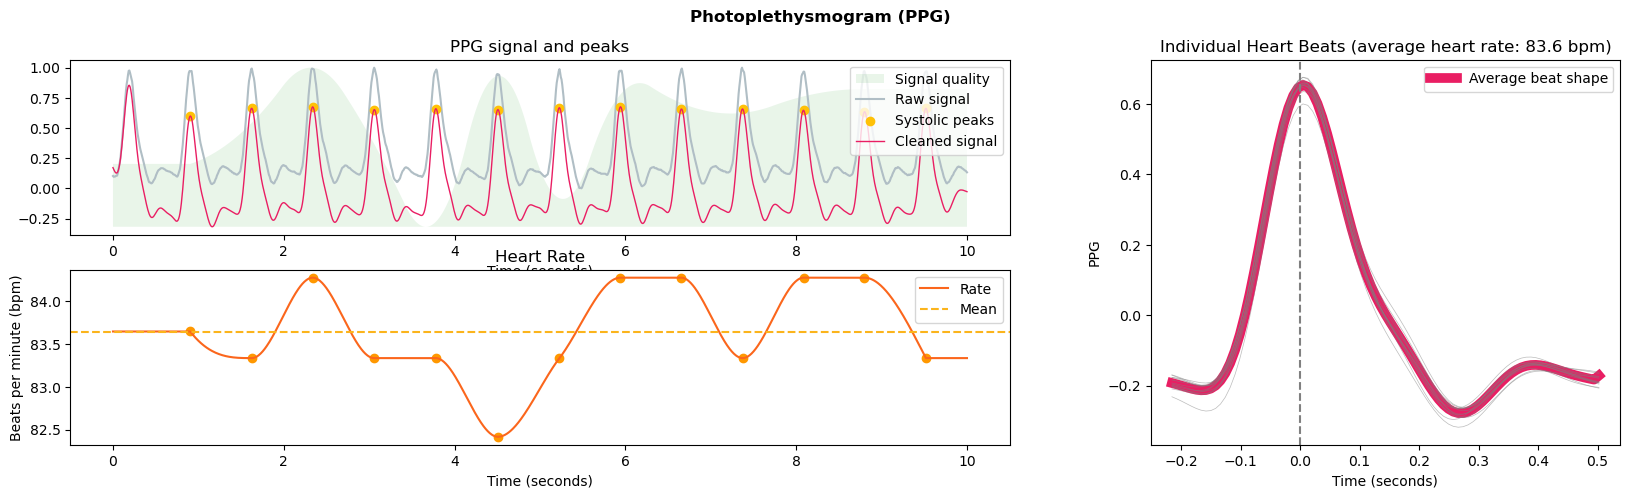

In [13]:
rand_idx = rng.choice(NB_TRAIN_SAMPLES)
ppg_signal = X_df["ppg"].iloc[rand_idx]
print(f"Signal#{rand_idx}")
signal, info = nk.ppg_process(ppg_signal, sampling_rate=SAMPLING_RATE)
nk.ppg_plot(signal, info)

In [14]:
ppg_ana = nk.ppg_analyze(signal, sampling_rate=SAMPLING_RATE)
ppg_ana.columns.to_list()

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid valu

['PPG_Rate_Mean',
 'HRV_MeanNN',
 'HRV_SDNN',
 'HRV_SDANN1',
 'HRV_SDNNI1',
 'HRV_SDANN2',
 'HRV_SDNNI2',
 'HRV_SDANN5',
 'HRV_SDNNI5',
 'HRV_RMSSD',
 'HRV_SDSD',
 'HRV_CVNN',
 'HRV_CVSD',
 'HRV_MedianNN',
 'HRV_MadNN',
 'HRV_MCVNN',
 'HRV_IQRNN',
 'HRV_SDRMSSD',
 'HRV_Prc20NN',
 'HRV_Prc80NN',
 'HRV_pNN50',
 'HRV_pNN20',
 'HRV_MinNN',
 'HRV_MaxNN',
 'HRV_HTI',
 'HRV_TINN',
 'HRV_ULF',
 'HRV_VLF',
 'HRV_LF',
 'HRV_HF',
 'HRV_VHF',
 'HRV_TP',
 'HRV_LFHF',
 'HRV_LFn',
 'HRV_HFn',
 'HRV_LnHF',
 'HRV_SD1',
 'HRV_SD2',
 'HRV_SD1SD2',
 'HRV_S',
 'HRV_CSI',
 'HRV_CVI',
 'HRV_CSI_Modified',
 'HRV_PIP',
 'HRV_IALS',
 'HRV_PSS',
 'HRV_PAS',
 'HRV_GI',
 'HRV_SI',
 'HRV_AI',
 'HRV_PI',
 'HRV_C1d',
 'HRV_C1a',
 'HRV_SD1d',
 'HRV_SD1a',
 'HRV_C2d',
 'HRV_C2a',
 'HRV_SD2d',
 'HRV_SD2a',
 'HRV_Cd',
 'HRV_Ca',
 'HRV_SDNNd',
 'HRV_SDNNa',
 'HRV_DFA_alpha1',
 'HRV_MFDFA_alpha1_Width',
 'HRV_MFDFA_alpha1_Peak',
 'HRV_MFDFA_alpha1_Mean',
 'HRV_MFDFA_alpha1_Max',
 'HRV_MFDFA_alpha1_Delta',
 'HRV_MFDFA_alpha

In [15]:
nan_columns = ppg_ana.columns[ppg_ana.isna().all()].tolist()
nan_columns

['HRV_SDANN1',
 'HRV_SDNNI1',
 'HRV_SDANN2',
 'HRV_SDNNI2',
 'HRV_SDANN5',
 'HRV_SDNNI5',
 'HRV_ULF',
 'HRV_VLF',
 'HRV_LF',
 'HRV_HF',
 'HRV_VHF',
 'HRV_LFHF',
 'HRV_LFn',
 'HRV_HFn',
 'HRV_LnHF',
 'HRV_MSEn',
 'HRV_CMSEn',
 'HRV_RCMSEn',
 'HRV_HFD']

In [16]:
rand_idx = rng.choice(NB_TRAIN_SAMPLES)
ppg_signal = X_df["ppg"].iloc[rand_idx]
signal, info = nk.ppg_process(ppg_signal, sampling_rate=SAMPLING_RATE)
ppg_ana = nk.ppg_analyze(signal, sampling_rate=SAMPLING_RATE)
nan_columns = ppg_ana.columns[ppg_ana.isna().all()].tolist()
nan_columns

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid valu

['HRV_SDANN1',
 'HRV_SDNNI1',
 'HRV_SDANN2',
 'HRV_SDNNI2',
 'HRV_SDANN5',
 'HRV_SDNNI5',
 'HRV_ULF',
 'HRV_VLF',
 'HRV_LF',
 'HRV_HF',
 'HRV_VHF',
 'HRV_LFHF',
 'HRV_LFn',
 'HRV_HFn',
 'HRV_LnHF',
 'HRV_MSEn',
 'HRV_CMSEn',
 'HRV_RCMSEn',
 'HRV_HFD']

In [17]:
def extract_ppg_features(one_ppg_as_list) -> pd.Series:
    """Extract relevant features from the ppg"""
    signal, info = nk.ppg_process(one_ppg_as_list, sampling_rate=SAMPLING_RATE)
    ppg_ana = nk.ppg_analyze(signal, SAMPLING_RATE)
    ppg_ana = ppg_ana[ppg_keep_cols].fillna(0.0)
    return ppg_ana.iloc[0]  # force return of Series


def safe_extract_ppg_features(one_ppg_as_list) -> pd.Series:
    """Extract relevant features from the ppg, return Series full of 0.0 if specific ValueError occurs."""
    try:
        return extract_ppg_features(one_ppg_as_list)
    except ValueError as e:
        if "NeuroKit error: the window" in str(e):
            return pd.Series(0.0, index=ppg_keep_cols)
        else:
            raise e


# Test
ppg_features_df_safe = (
    X_df["ppg"].iloc[100:200].apply(safe_extract_ppg_features)
)
ppg_features_df_safe

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid valu

,PPG_Rate_Mean,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,HRV_TP,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_S,HRV_CSI,HRV_CVI,HRV_CSI_Modified,HRV_PIP,HRV_IALS,HRV_PSS,HRV_PAS,HRV_GI,HRV_SI,HRV_AI,HRV_PI,HRV_C1d,HRV_C1a,HRV_SD1d,HRV_SD1a,HRV_C2d,HRV_C2a,HRV_SD2d,HRV_SD2a,HRV_Cd,HRV_Ca,HRV_SDNNd,HRV_SDNNa,HRV_DFA_alpha1,HRV_MFDFA_alpha1_Width,HRV_MFDFA_alpha1_Peak,HRV_MFDFA_alpha1_Mean,HRV_MFDFA_alpha1_Max,HRV_MFDFA_alpha1_Delta,HRV_MFDFA_alpha1_Asymmetry,HRV_MFDFA_alpha1_Fluctuation,HRV_MFDFA_alpha1_Increment,HRV_ApEn,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_CD,HRV_KFD,HRV_LZC
100,92.768763,647.428571,15.834307,27.083915,28.124266,0.024457,0.041833,648.0,11.8608,0.018304,22.0,0.584639,632.0,656.0,7.142857,50.000000,624.0,680.0,4.666667,0.0000,0.0,19.886859,10.945084,1.816967,683.809596,0.550368,3.541905,24.095282,0.714286,0.909091,1.0,0.333333,54.285714,54.320004,54.250689,45.454545,0.597315,0.402685,15.405627,12.649111,0.115648,0.884352,3.722102,10.292756,0.485735,0.514265,11.206859,11.531280,0.160360,1.240258,0.362513,0.466311,-0.106952,-0.299368,-0.416310,0.000301,0.086192,0.133233,inf,2.645593,1.725109,9.417630e-01,3.200742,1.631724
101,93.276083,643.428571,10.739677,17.186757,17.888544,0.016691,0.026711,644.0,5.9304,0.009209,8.0,0.624881,640.0,651.2,0.000000,14.285714,616.0,656.0,2.800000,31.2500,0.0,12.649111,9.369892,1.349974,372.344067,0.740755,3.277915,27.763176,0.857143,1.000000,1.0,1.000000,50.000000,50.000418,49.999571,44.444444,0.483333,0.516667,8.793937,9.092121,0.547987,0.452013,6.936170,6.299557,0.506240,0.493760,7.919715,7.821480,0.259055,1.801066,0.735748,0.654696,0.115264,0.249528,-0.545002,0.001702,0.253743,0.017709,0.693147,2.067031,0.985507,1.088390e+00,3.317360,1.631724
102,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
103,89.864456,667.692308,5.281802,8.000000,8.355727,0.007911,0.011982,664.0,0.0000,0.000000,8.0,0.660225,664.0,672.0,0.000000,0.000000,664.0,680.0,1.625000,0.0000,0.0,5.908392,4.824182,1.224745,89.545297,0.816497,2.659013,15.755711,0.769231,0.888889,1.0,0.500000,50.000000,50.000706,49.999289,44.444444,0.416667,0.583333,3.813850,4.512609,0.687500,0.312500,4.000000,2.696799,0.525000,0.475000,3.908034,3.717282,0.456357,0.840632,0.611773,0.563102,0.432261,0.221471,-0.557897,0.000079,0.036353,0.325150,0.510826,1.238901,0.871222,-2.634666e-16,2.838373,1.707895
104,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,86.591675,692.923077,19.194016,34.331715,35.851546,0.027700,0.049546,696.0,11.8608,0.017041,24.0,0.559075,675.2,704.0,15.384615,61.538462,664.0,728.0,3.250000,54.6875,0.0,25.350871,12.562571,2.017968,1000.509641,0.495548,3.707191,24.90142

In [18]:
ppg_features_df_safe.describe()

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,PPG_Rate_Mean,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,HRV_TP,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_S,HRV_CSI,HRV_CVI,HRV_CSI_Modified,HRV_PIP,HRV_IALS,HRV_PSS,HRV_PAS,HRV_GI,HRV_SI,HRV_AI,HRV_PI,HRV_C1d,HRV_C1a,HRV_SD1d,HRV_SD1a,HRV_C2d,HRV_C2a,HRV_SD2d,HRV_SD2a,HRV_Cd,HRV_Ca,HRV_SDNNd,HRV_SDNNa,HRV_DFA_alpha1,HRV_MFDFA_alpha1_Width,HRV_MFDFA_alpha1_Peak,HRV_MFDFA_alpha1_Mean,HRV_MFDFA_alpha1_Max,HRV_MFDFA_alpha1_Delta,HRV_MFDFA_alpha1_Asymmetry,HRV_MFDFA_alpha1_Fluctuation,HRV_MFDFA_alpha1_Increment,HRV_ApEn,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_CD,HRV_KFD,HRV_LZC
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.000000,100.000000
mean,68.444941,507.620777,11.188086,18.000158,18.721346,0.016641,0.026775,507.68000,11.149152,0.016610,14.260000,0.487057,498.784000,515.872000,3.820513,25.455495,489.360000,526.560000,2.508488,16.171875,0.0,13.237991,8.304097,1.234429,520.696476,0.516296,2.584530,23.229555,0.522647,0.634464,0.750508,0.350000,39.459168,39.452716,39.465705,35.465890,0.383029,0.376971,9.350136,9.343277,0.434112,0.325888,6.305153,5.166592,0.398347,0.361653,8.093274,7.682046,0.251525,0.764810,0.391842,0.426454,0.117116,-0.126985,-0.351377,3.478048e-04,0.064927,0.113313,NaN,1.763101,1.352369,6.307941e-01,3.313650,1.047688
std,38.816245,288.040276,8.478431,14.586382,15.223676,0.012232,0.020953,288.11091,8.971354,0.013063,11.750452,0.290176,282.899355,292.880327,9.720346,22.763445,277.636326,299.169231,1.661555,19.527462,0.0,10.764765,5.988949,0.815986,620.267805,0.372764,1.493308,21.505343,0.306861,0.369589,0.425300,0.343286,22.966256,22.959031,22.973816,21.143382,0.237627,0.234517,7.649212,7.720331,0.294590,0.246063,4.898586,3.795537,0.232878,0.212923,6.270798,5.913192,0.262745,0.641400,0.331596,0.358358,0.358960,0.384347,0.220828,9.391841e-04,0.104354,0.125898,NaN,1.062251,0.905735,7.080009e-01,6.178308,0.623991
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.005319,0.000000,0.000000,0.000000,-0.548518,-1.060204,-0.727002,0.000000e+00,0.000000,0.000000,-inf,0.000000,0.000000,-5.865901e-16,-45.959578,0.000000
25%,77.672985,618.428571,5.516210,8.226494,8.338247,0.008357,0.011860,619.00000,0.000000,0.000000,3.000000,0.539631,604.800000,622.000000,0.000000,0.000000,598.000000,632.000000,1.475000,0.000000,0.0,5.896031,3.651154,0.646714,84.083678,0.318071,2.628647,6.387235,0.482143,0.584615,0.851190,0.000000,40.000000,39.954557,40.048312,27.500000,0.297047,0.179945,3.773259,2.568534,0.138410,0.066914,2.041882,2.371494,0.380035,0.279078,4.048638,3.495068,0.015118,0.061095,0.107145,0.094609,-0.053688,-0.382236,-0.511380,1.602587e-08,0.000159,0.015487,0.000000,1.226356,0.855071,0.000000e+00,0.872417,0.876146
50%,89.688501,655.120879,11.768403,18.025105,18.788191,0.017150,0.027068,656.00000,11.860800,0.017863,15.000000,0.602824,640.000000,664.000000,0.000000,23.076923,632.000000,6

## 4. DataProcessing Pipeline